# M1 Scale — EDA Inspection Notebook

**Purpose:** Interactive inspection of a pre-generated M1 quality report artifact.

**Rules:**
- Zero network requests.
- Does not crawl, does not modify raw/canonical/derived artifacts.
- Does not write new research results by default.
- Reads one **explicit** quality artifact directory (configure in Cell 1).
- Business logic lives in `src/delta_t1/`, not here.

**Source of truth:** `report.json`, `per_symbol.jsonl`, and `plots/` inside the artifact.

> **Warning — Research gate remains PARTIAL.**  
> Historical identity, financial PIT, and research sample-size policy are **unresolved**.  
> `market_feature_stage_ready = True` only means canonical promotion succeeded and the  
> market feature artifact was generated. It does **not** open M2 or approve clustering.

In [1]:
# ============================================================
# Cell 1: CONFIGURE — edit this path before running
# ============================================================
from pathlib import Path

# Set to the explicit quality report directory you want to inspect.
# Do NOT use 'latest' — reproducibility requires an explicit artifact ID.
QUALITY_REPORT_DIR = Path(
    "../../data/derived/m1_scale_quality/m1-scale-quality-20260918T152429Z-dcbd8e8e"
)
# Fallback if running from repository root rather than notebooks/eda/
if not QUALITY_REPORT_DIR.exists() and Path("data/derived/m1_scale_quality/m1-scale-quality-20260918T152429Z-dcbd8e8e").exists():
    QUALITY_REPORT_DIR = Path("data/derived/m1_scale_quality/m1-scale-quality-20260918T152429Z-dcbd8e8e")

assert QUALITY_REPORT_DIR.exists(), (
    f"Quality report directory not found: {QUALITY_REPORT_DIR.resolve()}\n"
    "Run scripts/report_m1_scale_quality.py first to generate the artifact."
)
print(f"Using quality report: {QUALITY_REPORT_DIR.name}")

Using quality report: m1-scale-quality-20260918T152429Z-dcbd8e8e


In [2]:
# ============================================================
# Cell 2: Load report.json
# ============================================================
import json

with open(QUALITY_REPORT_DIR / "report.json", encoding="utf-8") as f:
    report = json.load(f)

print(f"report_id        : {report['report_id']}")
print(f"generated_at     : {report['generated_at']}")
print(f"canonical_run_id : {report['canonical_run_id']}")
print(f"m1_status        : {report['m1_status']}")
print(f"m1_gate_status   : {report['m1_gate_status']}")
print(f"network_requests : {report['network_requests']}")

report_id        : m1-scale-quality-20260918T152429Z-dcbd8e8e
generated_at     : 2026-09-18T15:24:29.895496+00:00
canonical_run_id : canonical-m1-scale-20260918T141019Z-7c003543
m1_status        : PARTIAL
m1_gate_status   : FAIL
network_requests : 0


In [3]:
# ============================================================
# Cell 3: Readiness summary
# ============================================================
readiness = {
    'market_feature_stage_ready': report.get('market_feature_stage_ready'),
    'feature_stage_ready (deprecated alias)': report.get('feature_stage_ready'),
    'research_stage_ready': report.get('research_stage_ready'),
}
print('Readiness:')
for k, v in readiness.items():
    mark = 'YES' if v else 'NO'
    print(f'  {mark:3s}  {k}: {v}')

print('\nBlocking reasons (research gate):')
for reason in report.get('blocking_reasons', []):
    print(f'  - {reason}')

print('\nWarning: Historical identity and financial PIT remain UNRESOLVED.')
print('  market_feature_stage_ready does NOT open M2 or approve research.')

Readiness:
  YES  market_feature_stage_ready: True
  NO   feature_stage_ready (deprecated alias): False
  NO   research_stage_ready: False

Blocking reasons (research gate):
  - historical_identity_ready_for_research
  - financial_pit_ready_for_research
  - research_sample_size_policy_resolved

  market_feature_stage_ready does NOT open M2 or approve research.


In [4]:
# ============================================================
# Cell 4: Summary metrics
# ============================================================
import pandas as pd

# Fallback for display() if running outside interactive IPython/Jupyter
if 'display' not in globals():
    display = print

summary = report['summary']
df_summary = pd.DataFrame([{'Metric': k, 'Value': v} for k, v in summary.items()])
display(df_summary.set_index('Metric'))

                                Value
Metric                               
benchmark_daily                  1667
feature_snapshots               39557
historical_identity_ready           0
latest_completed_snapshot  2026-08-28
latest_feature_complete           169
legacy_scoped_eligible              0
market_feature_ready              169
observed_span_3y                  500
observed_span_5y                  484
prices_daily                   614430
quarantined_rows                 3301
research_ready                      0
selected_symbols                  500


In [5]:
# ============================================================
# Cell 5: Required feature availability
# ============================================================
feat_cov = report['latest_feature_coverage']
df_feat = pd.DataFrame([
    {'Feature': k, 'Available': v['available'], 'Missing': v['missing']}
    for k, v in feat_cov.items()
])
df_feat['Available%'] = (df_feat['Available'] / summary['selected_symbols'] * 100).round(1)
display(df_feat.set_index('Feature').sort_values('Missing', ascending=False))

              Available  Missing  Available%
Feature                                     
mom_252             169      331        33.8
beta_126            184      316        36.8
mdd_126             184      316        36.8
mom_126             184      316        36.8
mom_63              193      307        38.6
vol_63              193      307        38.6
mom_21              213      287        42.6
liquidity_21        215      285        43.0


In [6]:
# ============================================================
# Cell 6: Exchange coverage
# ============================================================
ex_cov = report['exchange_coverage']
df_ex = pd.DataFrame([
    {'Exchange': k, 'Securities': v['securities'], 'Price rows': v['price_rows']}
    for k, v in sorted(ex_cov.items())
])
display(df_ex.set_index('Exchange'))

          Securities  Price rows
Exchange                        
HNX              116      146648
HOSE             158      244486
UPCOM            226      223296



--- 1. Securities by Exchange ---


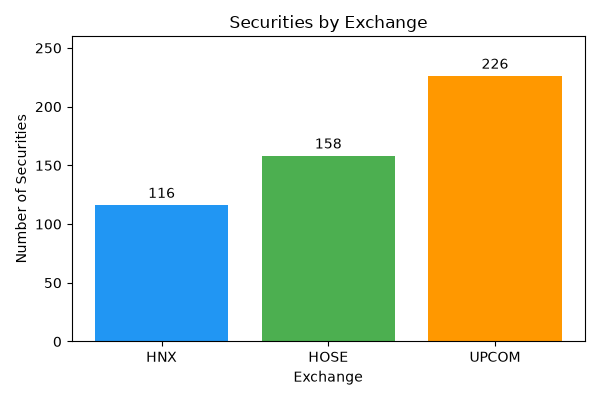


--- 2. Coverage vs. Observed Exchange Sessions ---


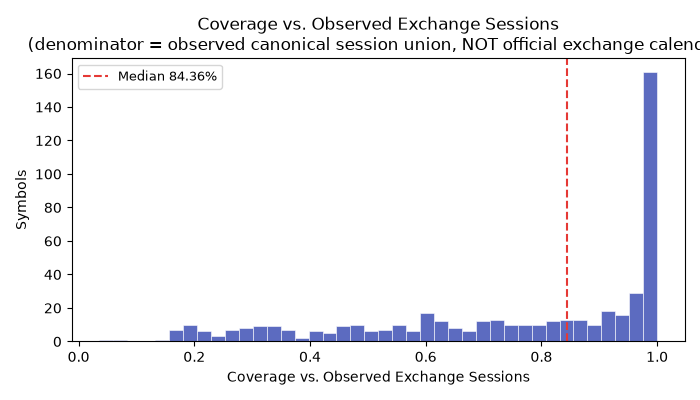


--- 3. Required Feature Availability ---


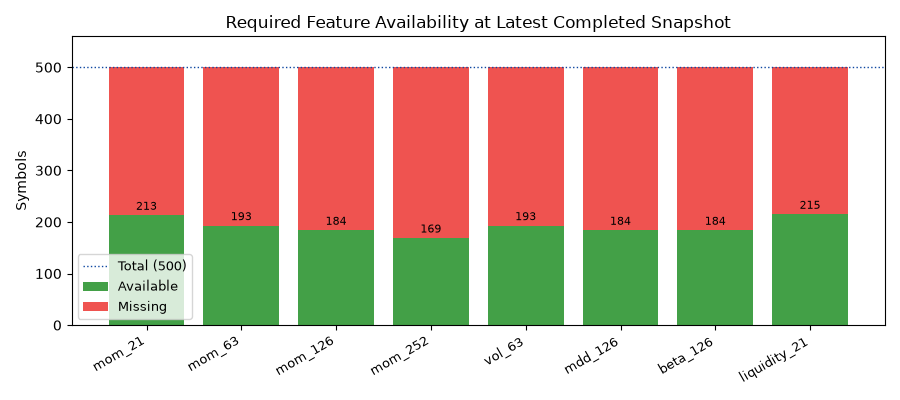


--- 4. Top Exclusion / Missing-Feature Reasons ---


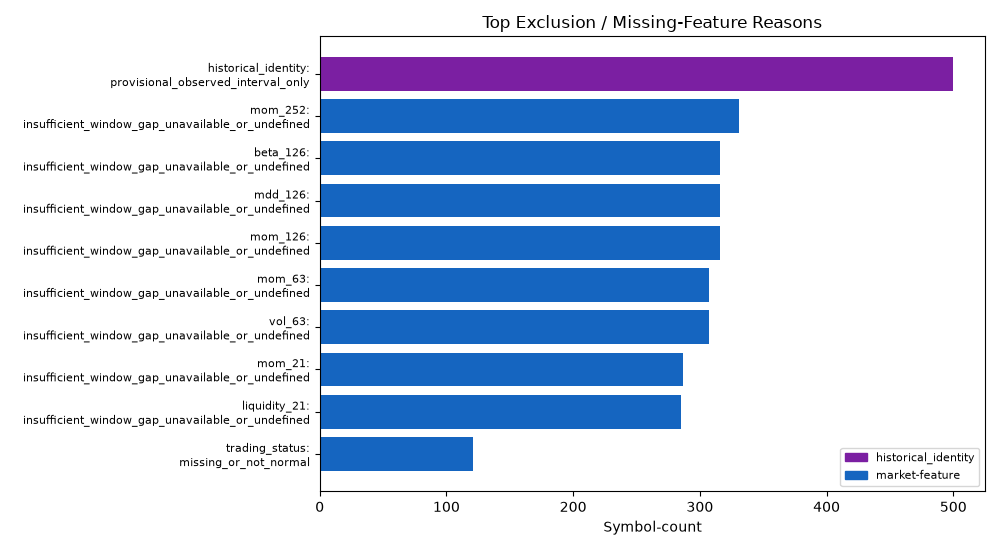

In [7]:
# ============================================================
# Cell 7: Display pre-generated EDA charts
# NOTE: session coverage denominator = observed canonical exchange-session union,
#       NOT a verified official HOSE/HNX/UPCOM exchange calendar.
# ============================================================
try:
    from IPython.display import Image, display as ipydisplay
except ImportError:
    Image = None
    ipydisplay = None

charts = [
    ('exchange_distribution.png',     '1. Securities by Exchange'),
    ('observed_session_coverage.png', '2. Coverage vs. Observed Exchange Sessions'),
    ('feature_availability.png',      '3. Required Feature Availability'),
    ('exclusion_reasons.png',         '4. Top Exclusion / Missing-Feature Reasons'),
]
plots_dir = QUALITY_REPORT_DIR / 'plots'
for fname, caption in charts:
    path = plots_dir / fname
    if path.exists():
        print(f'\n--- {caption} ---')
        if Image and ipydisplay:
            ipydisplay(Image(filename=str(path)))
        else:
            print(f'[{path.name}] ({path.stat().st_size:,} bytes) - rendered in Jupyter notebook')
    else:
        print(f'[missing] {caption}: run pip install -e .[research] and regenerate')

In [8]:
# ============================================================
# Cell 8: Load per_symbol.jsonl
# ============================================================
rows = []
with open(QUALITY_REPORT_DIR / 'per_symbol.jsonl', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} symbols')
print(f'Columns: {list(df.columns)}')

Loaded 500 symbols
Columns: ['exchange', 'expected_open_sessions_in_observed_range', 'historical_identity_ready', 'latest_completed_snapshot', 'latest_feature_complete', 'latest_na_reason', 'latest_universe_segment', 'legacy_scoped_eligibility', 'market_feature_ready', 'missing_required_features', 'missing_sessions_in_observed_range', 'observed_first_date', 'observed_last_date', 'observed_open_sessions', 'observed_session_coverage', 'observed_span_3y', 'observed_span_5y', 'price_rows', 'recent_lookback_observations', 'recent_missing_sessions', 'research_ready', 'security_id', 'ticker']


In [9]:
# ============================================================
# Cell 9: Highest session coverage vs. observed exchange sessions (top 10)
# Denominator = observed canonical exchange-session union
# (NOT a verified official exchange calendar)
# ============================================================
cols = ['ticker', 'exchange', 'observed_first_date', 'observed_last_date',
        'price_rows', 'observed_session_coverage', 'market_feature_ready']
print('=== Highest coverage vs. observed exchange sessions (top 10) ===')
display(
    df[cols].dropna(subset=['observed_session_coverage'])
      .sort_values('observed_session_coverage', ascending=False)
      .head(10).reset_index(drop=True)
)

=== Highest coverage vs. observed exchange sessions (top 10) ===
  ticker exchange observed_first_date observed_last_date  price_rows  \
0    HCM     HOSE          2020-01-02         2026-09-15        1670   
1    CRE     HOSE          2020-01-02         2026-09-15        1670   
2    VPG     HOSE          2020-01-02         2026-09-15        1670   
3    HDC     HOSE          2020-01-02         2026-09-15        1670   
4    CMX     HOSE          2020-01-02         2026-09-15        1670   
5    HID     HOSE          2020-01-02         2026-09-15        1670   
6    HLD      HNX          2020-01-02         2026-09-15        1670   
7    SSB     HOSE          2021-03-24         2026-09-15        1366   
8    VGC     HOSE          2020-01-02         2026-09-15        1670   
9    TNT     HOSE          2020-01-02         2026-09-15        1670   

   observed_session_coverage  market_feature_ready  
0                        1.0                  True  
1                        1.0        

In [10]:
# ============================================================
# Cell 10: Lowest session coverage (bottom 10)
# ============================================================
print('=== Lowest coverage vs. observed exchange sessions (bottom 10) ===')
display(
    df[cols].dropna(subset=['observed_session_coverage'])
      .sort_values('observed_session_coverage', ascending=True)
      .head(10).reset_index(drop=True)
)

=== Lowest coverage vs. observed exchange sessions (bottom 10) ===
  ticker exchange observed_first_date observed_last_date  price_rows  \
0    DDH    UPCOM          2020-08-05         2026-09-10          55   
1    HLS    UPCOM          2020-01-21         2026-09-03         118   
2    KHW    UPCOM          2020-03-02         2026-09-15         229   
3    BMV    UPCOM          2020-02-19         2026-09-11         258   
4    USC    UPCOM          2020-11-24         2026-09-14         239   
5    CPI    UPCOM          2020-01-03         2026-09-11         284   
6    LTC    UPCOM          2020-01-17         2026-09-11         283   
7    STT    UPCOM          2020-03-13         2026-09-11         281   
8    NOS    UPCOM          2020-01-10         2026-09-11         289   
9    CMI    UPCOM          2020-01-03         2026-09-11         301   

   observed_session_coverage  market_feature_ready  
0                   0.036160                 False  
1                   0.071559      

In [11]:
# ============================================================
# Cell 11: market_feature_ready symbols
# ============================================================
mfr = df[df['market_feature_ready'] == True].copy()
print(f'market_feature_ready: {len(mfr)} / {len(df)} symbols')
display(
    mfr[['ticker', 'exchange', 'observed_first_date', 'observed_last_date',
         'price_rows', 'observed_session_coverage']]
      .sort_values('ticker').head(20).reset_index(drop=True)
)

market_feature_ready: 169 / 500 symbols
   ticker exchange observed_first_date observed_last_date  price_rows  \
0     AAS    UPCOM          2020-07-23         2026-09-15        1533   
1     ABI    UPCOM          2020-01-02         2026-09-15        1664   
2     ABW    UPCOM          2023-05-30         2026-09-15         822   
3     ACV    UPCOM          2020-01-02         2026-09-15        1661   
4     ADS     HOSE          2020-01-02         2026-09-15        1664   
5     AGR     HOSE          2020-01-02         2026-09-15        1670   
6     ANV     HOSE          2020-01-02         2026-09-15        1670   
7     APS      HNX          2020-01-02         2026-09-15        1652   
8     BAB      HNX          2020-01-02         2026-09-15        1628   
9     BCE     HOSE          2020-01-02         2026-09-15        1670   
10    BCM     HOSE          2020-01-03         2026-09-15        1660   
11    BFC     HOSE          2020-01-02         2026-09-15        1670   
12    BIG  

In [12]:
# ============================================================
# Cell 12: Symbols missing mom_252
# ============================================================
missing_mom252 = df[
    df['missing_required_features'].apply(
        lambda x: 'mom_252' in x if isinstance(x, list) else False
    )
].copy()
print(f'Symbols missing mom_252: {len(missing_mom252)} / {len(df)}')
display(
    missing_mom252[['ticker', 'exchange', 'observed_first_date', 'observed_last_date',
                    'price_rows', 'observed_session_coverage', 'market_feature_ready']]
      .sort_values('price_rows', ascending=False).head(20).reset_index(drop=True)
)

Symbols missing mom_252: 331 / 500
   ticker exchange observed_first_date observed_last_date  price_rows  \
0     STK     HOSE          2020-01-02         2026-09-15        1669   
1     IDV      HNX          2020-01-02         2026-09-15        1667   
2     ITD     HOSE          2020-01-02         2026-09-15        1666   
3     HND    UPCOM          2020-01-02         2026-09-15        1665   
4     AAV    UPCOM          2020-01-02         2026-09-15        1663   
5     TVB     HOSE          2020-01-02         2026-09-15        1663   
6     AST     HOSE          2020-01-02         2026-09-15        1660   
7     MCH     HOSE          2020-01-03         2026-09-15        1660   
8     UDC    UPCOM          2020-01-02         2026-09-15        1660   
9     SLS      HNX          2020-01-02         2026-09-15        1660   
10    KHP     HOSE          2020-01-06         2026-09-15        1659   
11    NTC     HOSE          2020-01-02         2026-09-15        1658   
12    THT      H

In [13]:
# ============================================================
# Cell 13: Top exclusion reasons
# ============================================================
df_reasons = pd.DataFrame([
    {'Reason': k, 'Count': v}
    for k, v in report.get('exclusion_reason_counts', {}).items()
]).sort_values('Count', ascending=False).head(20)
display(df_reasons.set_index('Reason'))

print('\nNote: historical_identity:provisional_observed_interval_only is expected.')
print('  Identity is observed-interval only, NOT complete historical membership.')
print('  This is NOT a market-feature calculation error.')

                                                    Count
Reason                                                   
historical_identity:provisional_observed_interv...    500
mom_252:insufficient_window_gap_unavailable_or_...    331
beta_126:insufficient_window_gap_unavailable_or...    316
mdd_126:insufficient_window_gap_unavailable_or_...    316
mom_126:insufficient_window_gap_unavailable_or_...    316
mom_63:insufficient_window_gap_unavailable_or_u...    307
vol_63:insufficient_window_gap_unavailable_or_u...    307
mom_21:insufficient_window_gap_unavailable_or_u...    287
liquidity_21:insufficient_window_gap_unavailabl...    285
trading_status:missing_or_not_normal                  121

Note: historical_identity:provisional_observed_interval_only is expected.
  Identity is observed-interval only, NOT complete historical membership.
  This is NOT a market-feature calculation error.


In [14]:
# ============================================================
# Cell 14: Final readiness status reminder
# ============================================================
print('=' * 60)
print('FINAL READINESS STATUS')
print('=' * 60)
print(f"  market_feature_stage_ready : {report.get('market_feature_stage_ready')}")
print(f"  research_stage_ready       : {report.get('research_stage_ready')}")
print(f"  feature_stage_ready (dep.) : {report.get('feature_stage_ready')}")
print('')
print('Unresolved blockers (research gate remains FAIL/PARTIAL):')
for b in report.get('blocking_reasons', []):
    print(f'  x {b}')
print('')
print('Do NOT proceed to M2 until all three blockers are resolved.')

FINAL READINESS STATUS
  market_feature_stage_ready : True
  research_stage_ready       : False
  feature_stage_ready (dep.) : False

Unresolved blockers (research gate remains FAIL/PARTIAL):
  x historical_identity_ready_for_research
  x financial_pit_ready_for_research
  x research_sample_size_policy_resolved

Do NOT proceed to M2 until all three blockers are resolved.
